# Stocker 2003 Bipolar Seesaw Demo

This notebook uses PaleoBeasts package APIs for model integration and noise overlays.

- Model dynamics: `Stocker2003BipolarSeesaw.integrate`
- Noise generation: `paleobeasts.utils.noise.from_param`
- Noise application/reversal: `PBModel.add_noise` / `PBModel.remove_noise`

Tau estimation remains notebook-local analysis logic by design.


In [26]:
import numpy as np
import matplotlib.pyplot as plt

import paleobeasts as pb
from paleobeasts.signal_models import Stocker2003BipolarSeesaw
from paleobeasts.utils import noise as noise_utils

try:
    import pyleoclim as pyleo
except Exception:
    pyleo = None


## Shared Configuration

Keep only values reused across multiple sections.

In [27]:
CONFIG = {
    't_start': 0.0,
    't_end': 70000.0,
    'dt': 20.0,
    'tau_true': 1000.0,
    'tau_grid': np.arange(100.0, 4000.0 + 1e-12, 20.0),
}

# Fixed coupling assumption for this demo (paper-consistent sign convention)
COUPLING_BETA = -1.0


## Synthetic Input + Notebook-Local Tau Scan Helper

The tau scan below is intentionally notebook-local analysis (not model API).


In [28]:
def synthetic_north_signal(time, on_duration=2000.0, off_duration=5000.0):
    time = np.asarray(time, dtype=float)
    period = on_duration + off_duration
    phase = np.mod(time, period)
    base = np.where(phase < on_duration, 1.0, -1.0)
    perturb = 0.12 * np.sin(2.0 * np.pi * time / 3100.0)
    return base + perturb


def estimate_tau_by_correlation(time, north, south_observed, tau_grid, y0=0.0):
    time = np.asarray(time, dtype=float).reshape(-1)
    north = np.asarray(north, dtype=float).reshape(-1)
    south_observed = np.asarray(south_observed, dtype=float).reshape(-1)
    tau_grid = np.asarray(tau_grid, dtype=float).reshape(-1)

    corrs = np.zeros_like(tau_grid, dtype=float)
    models = []
    dt = float(np.median(np.diff(time)))
    t_span = (float(time[0]), float(time[-1]))
    forcing = pb.Forcing(data=north, time=time, interpolation='linear')

    for i, tau in enumerate(tau_grid):
        m = Stocker2003BipolarSeesaw(
            forcing=forcing,
            tau=float(tau),
            beta=float(COUPLING_BETA),
            parameter_contract='strict',
        )
        m.integrate(t_span=t_span, y0=[float(y0)], method='euler', kwargs={'dt': dt})
        ts = np.asarray(m.state_variables['Ts'], dtype=float)
        models.append(ts)
        if np.std(ts) == 0 or np.std(south_observed) == 0:
            corrs[i] = 0.0
        else:
            corrs[i] = np.corrcoef(south_observed, ts)[0, 1]

    best_idx = int(np.nanargmax(corrs))
    return {
        'best_tau': float(tau_grid[best_idx]),
        'best_corr': float(corrs[best_idx]),
        'tau_grid': tau_grid,
        'correlations': corrs,
        'south_modeled_best': models[best_idx],
    }


## Model Integration (Package API)

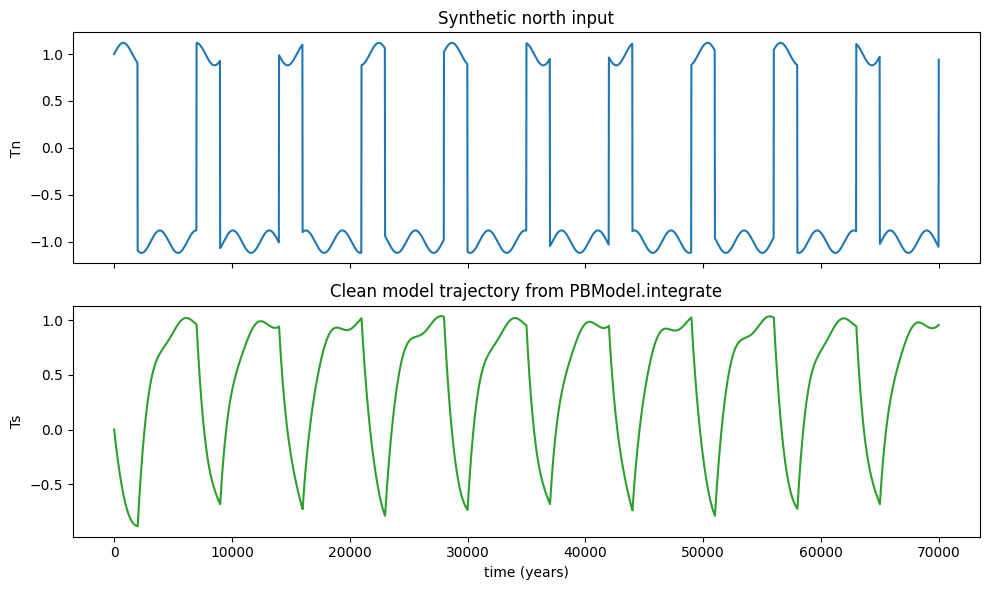

In [29]:
time = np.arange(CONFIG['t_start'], CONFIG['t_end'] + CONFIG['dt'], CONFIG['dt'])
north = synthetic_north_signal(time)

forcing = pb.Forcing(data=north, time=time, interpolation='linear')
model = Stocker2003BipolarSeesaw(
    forcing=forcing,
    tau=float(CONFIG['tau_true']),
    beta=float(COUPLING_BETA),
    parameter_contract='strict',
)
model.integrate(
    t_span=(float(time[0]), float(time[-1])),
    y0=[0.0],
    method='euler',
    kwargs={'dt': float(CONFIG['dt'])},
)
south_clean = model.state_variables['Ts'].copy()

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(time, north, color='tab:blue')
ax[0].set_ylabel('Tn')
ax[0].set_title('Synthetic north input')
ax[1].plot(model.time, model.state_variables['Ts'], color='tab:green')
ax[1].set_ylabel('Ts')
ax[1].set_xlabel('time (years)')
ax[1].set_title('Clean model trajectory from PBModel.integrate')
plt.tight_layout()


## Noise Generation + PBModel Noise Overlay (Package API)

Noise is generated from `paleobeasts.utils.noise.from_param(...)` and applied via
`model.add_noise('Ts', noise_ts)`. We then demonstrate `remove_noise('Ts')`.

This section keeps the existing AR(1) example. A white-noise example follows.


In [30]:
# AR(1) noise settings (section-local)
ar_noise_tau = 1.0
ar_noise_target_std_fraction = 0.25
ar_noise_seed = 42

noise_surr = noise_utils.from_param(
    method='ar1sim',
    noise_param=[ar_noise_tau, 1.0],
    time_pattern='specified',
    settings={'time': model.time},
    seed=ar_noise_seed,
)
raw_noise = np.asarray(noise_surr.series_list[0].value, dtype=float)

noise_scale = ar_noise_target_std_fraction * np.std(south_clean)
if np.std(raw_noise) > 0:
    noise_ts = raw_noise * (noise_scale / np.std(raw_noise))
else:
    noise_ts = raw_noise.copy()

model.add_noise('Ts', noise_ts)
south_noisy_series = model.to_pyleo(var_names='Ts')
south_noisy = np.asarray(south_noisy_series.value, dtype=float)

model.remove_noise('Ts')
south_restored = model.state_variables['Ts'].copy()
ar_restored_ok = np.allclose(south_restored, south_clean, atol=1e-8)
print('remove_noise restored clean trajectory (AR1):', ar_restored_ok)


remove_noise restored clean trajectory (AR1): True


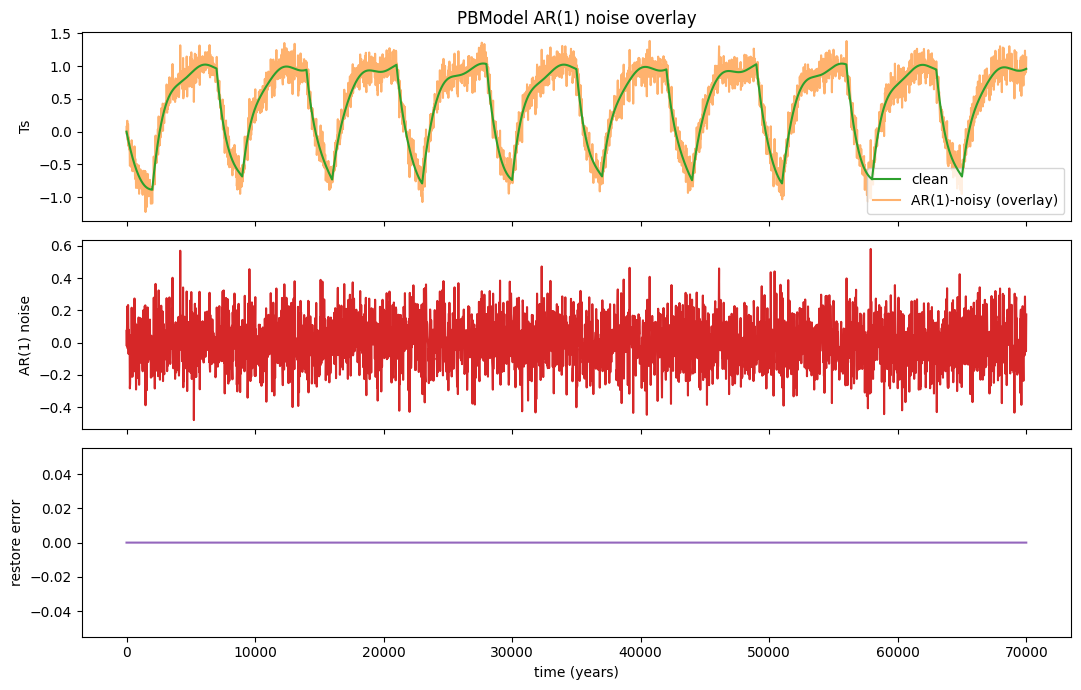

In [31]:
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(model.time, south_clean, color='tab:green', label='clean', zorder=10)
ax[0].plot(model.time, south_noisy, color='tab:orange', alpha=0.6, label='AR(1)-noisy (overlay)')
ax[0].legend(loc='best')
ax[0].set_ylabel('Ts')
ax[0].set_title('PBModel AR(1) noise overlay')
ax[1].plot(model.time, noise_ts, color='tab:red')
ax[1].set_ylabel('AR(1) noise')
ax[2].plot(model.time, south_restored - south_clean, color='tab:purple')
ax[2].set_ylabel('restore error')
ax[2].set_xlabel('time (years)')
plt.tight_layout()


## White-Noise Perturbation Example

This section uses the same package-first workflow with white noise generated by
`paleobeasts.utils.noise.from_param(...)` and applied with `model.add_noise`.


In [32]:
# White-noise settings (section-local)
white_noise_method = 'CN'
white_noise_param = [0.0]
white_noise_target_std_fraction = 0.25
white_noise_seed = 123

white_noise_surr = noise_utils.from_param(
    method=white_noise_method,
    noise_param=white_noise_param,
    time_pattern='specified',
    settings={'time': model.time},
    seed=white_noise_seed,
)
raw_white_noise = np.asarray(white_noise_surr.series_list[0].value, dtype=float)

white_noise_scale = white_noise_target_std_fraction * np.std(south_clean)
if np.std(raw_white_noise) > 0:
    white_noise_ts = raw_white_noise * (white_noise_scale / np.std(raw_white_noise))
else:
    white_noise_ts = raw_white_noise.copy()

model.add_noise('Ts', white_noise_ts)
south_white_noisy_series = model.to_pyleo(var_names='Ts')
south_white_noisy = np.asarray(south_white_noisy_series.value, dtype=float)

model.remove_noise('Ts')
white_restored = model.state_variables['Ts'].copy()
white_restored_ok = np.allclose(white_restored, south_clean, atol=1e-8)
print('remove_noise restored clean trajectory (white):', white_restored_ok)
print('white noise method:', white_noise_method, 'param:', white_noise_param)


remove_noise restored clean trajectory (white): True
white noise method: CN param: [0.0]


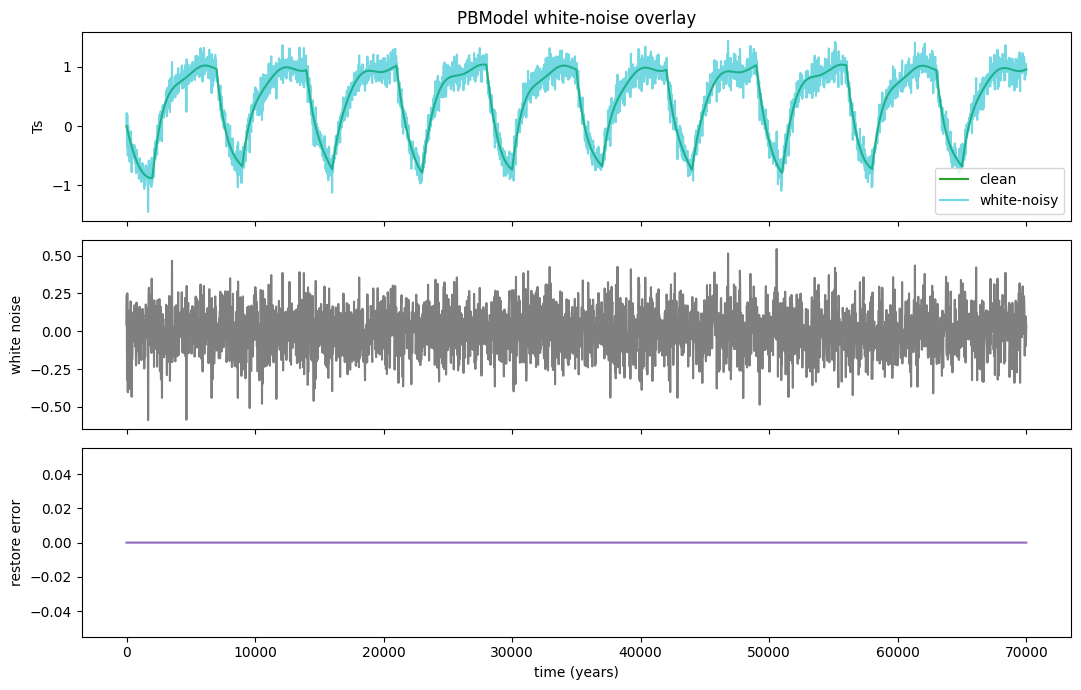

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(model.time, south_clean, color='tab:green', label='clean')
ax[0].plot(model.time, south_white_noisy, color='tab:cyan', alpha=0.6, label='white-noisy')
ax[0].set_ylabel('Ts')
ax[0].set_title('PBModel white-noise overlay')
ax[0].legend(loc='best')
ax[1].plot(model.time, white_noise_ts, color='tab:gray')
ax[1].set_ylabel('white noise')
ax[2].plot(model.time, white_restored - south_clean, color='tab:purple')
ax[2].set_ylabel('restore error')
ax[2].set_xlabel('time (years)')
plt.tight_layout()




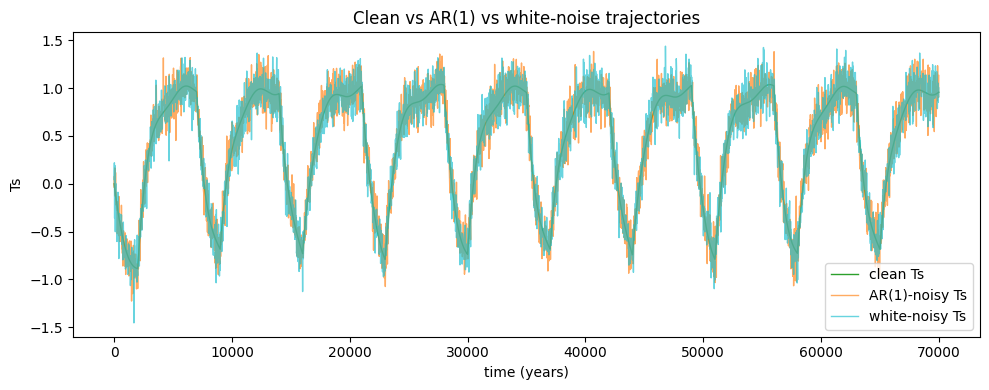

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(model.time, south_clean, lw=1.0, color='tab:green', label='clean Ts')
ax.plot(model.time, south_noisy, lw=1.0, alpha=0.65, color='tab:orange', label='AR(1)-noisy Ts')
ax.plot(model.time, south_white_noisy, lw=1.0, alpha=0.65, color='tab:cyan', label='white-noisy Ts')
ax.set_xlabel('time (years)')
ax.set_ylabel('Ts')
ax.set_title('Clean vs AR(1) vs white-noise trajectories')
ax.legend(loc='best')
plt.tight_layout()

## Tau Scan (Notebook Analysis)

This section computes correlation-vs-tau from package-generated trajectories.


tau_true = 1000.0 years
best_tau = 1000.0 years
best_corr = 0.9702


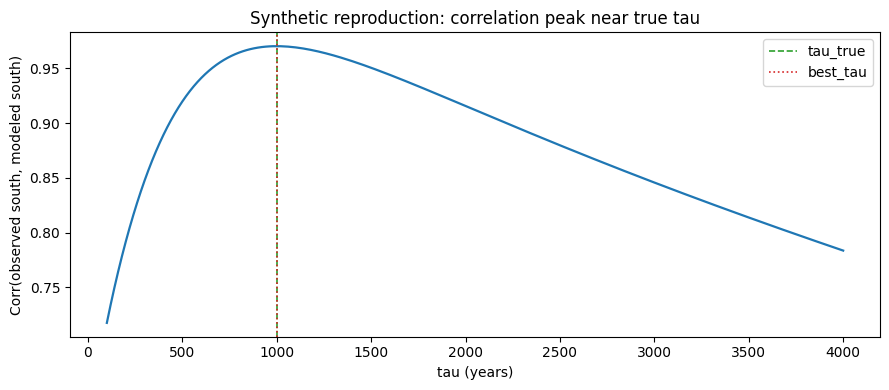

In [9]:
result = estimate_tau_by_correlation(
    time=time,
    north=north,
    south_observed=south_noisy,
    tau_grid=CONFIG['tau_grid'],
    y0=0.0,
)

print(f"tau_true = {CONFIG['tau_true']:.1f} years")
print(f"best_tau = {result['best_tau']:.1f} years")
print(f"best_corr = {result['best_corr']:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(result['tau_grid'], result['correlations'], lw=1.6)
ax.axvline(CONFIG['tau_true'], color='tab:green', ls='--', lw=1.2, label='tau_true')
ax.axvline(result['best_tau'], color='tab:red', ls=':', lw=1.2, label='best_tau')
ax.set_xlabel('tau (years)')
ax.set_ylabel('Corr(observed south, modeled south)')
ax.set_title('Synthetic reproduction: correlation peak near true tau')
ax.legend(loc='best')
plt.tight_layout()


## Optional Pyleoclim Preprocessing Example (Notebook-Owned)

best_tau (with preprocessing) = 940.0 years


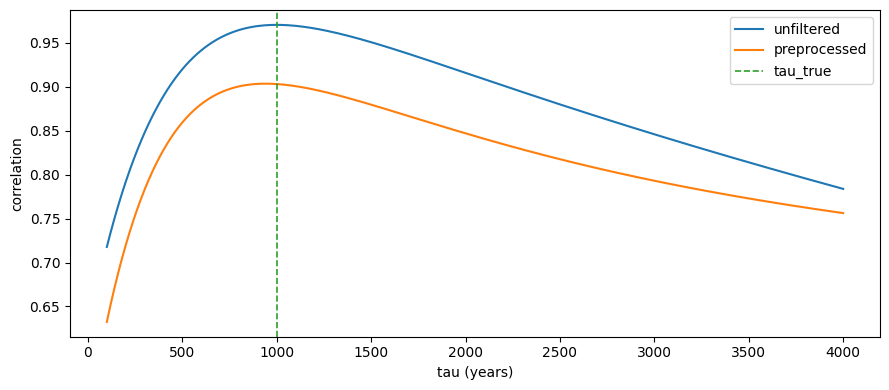

In [10]:
if pyleo is None:
    print('Skipping preprocessing section: pyleoclim is unavailable.')
else:
    highpass_cutoff_scale = 8000.0

    north_series = model.to_pyleo(var_names='Tn')
    low_north = north_series.filter(cutoff_scale=highpass_cutoff_scale, method='butterworth')
    low_south = south_noisy_series.filter(cutoff_scale=highpass_cutoff_scale, method='butterworth')

    north_hp = np.asarray(north_series.value, dtype=float) - np.asarray(low_north.value, dtype=float)
    south_hp = np.asarray(south_noisy_series.value, dtype=float) - np.asarray(low_south.value, dtype=float)
    time_hp = np.asarray(north_series.time, dtype=float)

    result_hp = estimate_tau_by_correlation(
        time=time_hp,
        north=north_hp,
        south_observed=south_hp,
        tau_grid=CONFIG['tau_grid'],
        y0=0.0,
    )
    print(f"best_tau (with preprocessing) = {result_hp['best_tau']:.1f} years")

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.plot(result['tau_grid'], result['correlations'], label='unfiltered', lw=1.5)
    ax.plot(result_hp['tau_grid'], result_hp['correlations'], label='preprocessed', lw=1.5)
    ax.axvline(CONFIG['tau_true'], color='tab:green', ls='--', lw=1.2, label='tau_true')
    ax.set_xlabel('tau (years)')
    ax.set_ylabel('correlation')
    ax.legend(loc='best')
    plt.tight_layout()
